# 03 — Specificity Analysis

Compute cell-type specificity metrics for all genes and identify
transcripts uniquely expressed in each cell type.

**Metrics applied:**
1. **Tau specificity index** (≥ 0.85)
2. **On-target mean CPM** (≥ 1.0)
3. **On-target detection rate** (≥ 25%)
4. **Off-target detection rate** (≤ 5% in all other cell types)
5. **Fold-change** (≥ 10× vs. next-highest cell type)

**Inputs:** Preprocessed data from Notebook 02  
**Outputs:** `results/specificity_scores.csv`

In [1]:
import sys
from pathlib import Path
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(name)s | %(message)s")

from src.specificity import (
    compute_tau, compute_fold_change, score_specificity,
    compute_composite_score, query_cell_type,
)
from src.filters import apply_post_filters

DATA_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
CT_REPORT_DIR = RESULTS_DIR / "cell_type_reports"
RESULTS_DIR.mkdir(exist_ok=True)
CT_REPORT_DIR.mkdir(exist_ok=True)

## 1. Load Preprocessed Data

In [2]:
# Raw CPM (for fold-change) and detection rate
mean_cpm = pd.read_parquet(DATA_DIR / "preprocessed_mean_cpm.parquet")
det_df = pd.read_parquet(DATA_DIR / "preprocessed_detection_rate.parquet")

# Log-transformed (for Tau — optional, score_specificity handles this internally)
mean_log = pd.read_parquet(DATA_DIR / "preprocessed_mean_log2cpm.parquet")

print(f"Loaded: {mean_cpm.shape[0]:,} genes × {mean_cpm.shape[1]} cell types")
print(f"Cell types: {list(mean_cpm.columns[:10])}...")

Loaded: 35,808 genes × 100 cell types
Cell types: ['neuron', 'oligodendrocyte', 'naive thymus-derived CD4-positive, alpha-beta T cell', 'fibroblast', 'glutamatergic neuron', 'central memory CD4-positive, alpha-beta T cell', 'L2/3-6 intratelencephalic projecting glutamatergic neuron', 'unknown', 'astrocyte', 'retinal rod cell']...


## 2. Compute Tau Specificity Index

Tau ranges from 0 (ubiquitous) to 1 (perfectly cell-type specific).

In [3]:
tau = compute_tau(mean_log)

print(f"Tau statistics:")
print(tau.describe())
print(f"\nGenes with Tau ≥ 0.85: {(tau >= 0.85).sum():,}")
print(f"Genes with Tau ≥ 0.90: {(tau >= 0.90).sum():,}")
print(f"Genes with Tau ≥ 0.95: {(tau >= 0.95).sum():,}")

Tau statistics:
count    30005.000000
mean         0.647945
std          0.252323
min          0.081226
25%          0.419611
50%          0.712496
75%          0.871248
max          0.999991
Name: tau, dtype: float64

Genes with Tau ≥ 0.85: 8,766
Genes with Tau ≥ 0.90: 5,664
Genes with Tau ≥ 0.95: 2,193


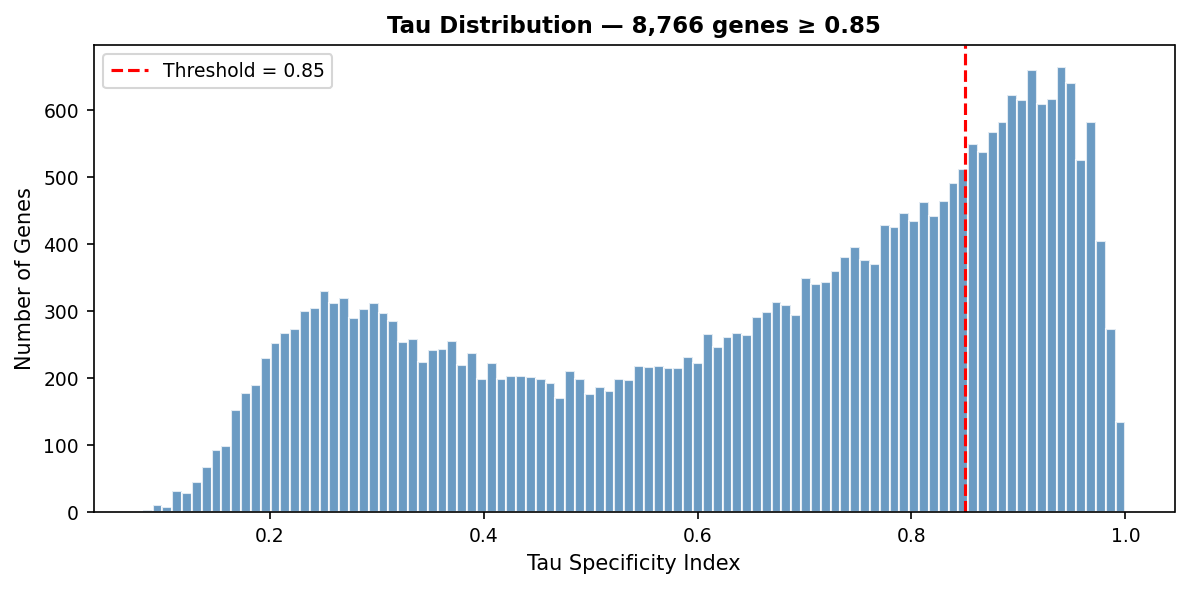

In [4]:
from src.visualization import plot_tau_distribution

fig = plot_tau_distribution(
    tau, threshold=0.85,
    save_path=str(RESULTS_DIR / "tau_distribution.png"),
)
plt.show()

## 3. Run Full Specificity Scoring

This applies all metrics simultaneously and returns a ranked long-form table.

In [5]:
results = score_specificity(
    mean_cpm=mean_cpm,
    det_df=det_df,
    tau_threshold=0.85,
    fc_threshold=10.0,
    on_target_det_min=0.25,
    off_target_det_max=0.05,
    on_target_expr_min=1.0,
)

print(f"Total gene-cell_type pairs with Tau ≥ 0.85: {len(results):,}")
print(f"Passing ALL thresholds: {results['all_pass'].sum():,}")
print(f"\nCell types with ≥1 specific gene: {results[results['all_pass']]['cell_type'].nunique()}")

2026-03-08 11:25:53,826 | src.specificity | Duplicate gene names detected (5913); keeping max-expression row per gene.
2026-03-08 11:25:56,144 | src.specificity | Specificity scoring: 8659 genes passed Tau > 0.85; 56 passed ALL thresholds


Total gene-cell_type pairs with Tau ≥ 0.85: 8,659
Passing ALL thresholds: 56

Cell types with ≥1 specific gene: 20


In [6]:
# Top hits overview
print("\nTop 20 most specific transcripts (passing all thresholds):")
display(results[results["all_pass"]].head(20))


Top 20 most specific transcripts (passing all thresholds):


,gene,cell_type,tau,mean_cpm,log2_cpm,detection_rate,fold_change,second_highest_cpm,max_off_target_det,on_target_expr_pass,on_target_det_pass,off_target_det_pass,fc_pass,all_pass
0,SLC22A12,epithelial cell of proximal tubule,0.9921,122.889999,6.95,0.2666,137.869995,0.790000,0.0056,True,True,True,True,True
1,PARAL1,alveolar macrophage,0.9861,89.660004,6.50,0.4534,19.870001,4.420000,0.0409,True,True,True,True,True
2,RAB41,retinal cone cell,0.9852,297.760010,8.22,0.7044,126.000000,2.260000,0.0077,True,True,True,True,True
3,ENSG00000236656,"double-positive, alpha-beta thymocyte",0.9818,401.429993,8.65,0.6384,20.620001,19.379999,0.0353,True,True,True,True,True
4,ENSG00000239311,retinal pigment epithelial cell,0.9802,305.609985,8.26,0.4337,52.020000,5.780000,0.0103,True,True,True,True,True
5,ENSG00000285831,pigmented ciliary epithelial cell,0.9788,245.809998,7.95,0.4114,39.560001,6.120000,0.0219,True,True,True,True,True
6,SLC17A1,epithelial cell of proximal tubule,0.9786,449.859985,8.82,0.3862,55.189999,8.050000,0.0204,True,True,True,True,True
7,NAT8,epithelial cell of proximal tubule,0.9757,669.590027,9.39,0.5101,37.930000,17.559999,0.0400,True,True,True,True,True
8,SKOR2,Purkinje cell,0.9714,252.550003,7.99,0.3087,46.139999,5.380000,0.0136,True,True,True,True,True
9,ENSG00000232130,retinal cone cell,0.9714,69.029999,6.13,0.2738,24.660000,2.700000,0.0093,True,True,True,True,True


## 4. Apply Post-Filters (Annotation Tiers)

Add annotation quality tiers. UniProt reviewed gene list and lncATLAS
data can be loaded here if available.

In [7]:
# Optional: load UniProt reviewed gene list if available
# from src.filters import load_uniprot_reviewed_genes
# uniprot_path = PROJECT_ROOT / "data" / "references" / "uniprot_reviewed_human.tsv"
# uniprot_reviewed = load_uniprot_reviewed_genes(uniprot_path) if uniprot_path.exists() else None

results_filtered = apply_post_filters(
    results,
    uniprot_reviewed=None,  # Replace with uniprot_reviewed when available
    lncatlas_df=None,       # Load lncATLAS if filtering lncRNAs
    gene_length_map=None,   # Load from Ensembl BioMart if needed
    min_length=200,
)

print(f"After post-filtering: {len(results_filtered):,} gene-cell_type pairs")
print(f"Passing all thresholds: {results_filtered['all_pass'].sum():,}")

2026-03-08 11:25:56,182 | src.filters | No UniProt reviewed set provided — all genes assigned Tier 2
2026-03-08 11:25:56,184 | src.filters | No lncATLAS data provided — skipping cytoplasmic filter
2026-03-08 11:25:56,187 | src.filters | No gene length data — skipping length filter
2026-03-08 11:25:56,188 | src.filters | Post-filtering complete: 8659 genes remain


After post-filtering: 8,659 gene-cell_type pairs
Passing all thresholds: 56


## 5b. Compute Composite Specificity Score

Combines Tau, fold-change, detection rate, expression level, and off-target detection
into a single weighted score in [0, 1] for ranking candidates within each cell type.

In [8]:
results_filtered = compute_composite_score(
    results_filtered,
    weight_tau=0.35,
    weight_fc=0.25,
    weight_detection=0.20,
    weight_expression=0.10,
    weight_off_target=0.10,
)

print("Composite score added. Score distribution (all_pass=True genes):")
pass_scores = results_filtered[results_filtered["all_pass"]]["composite_score"]
print(pass_scores.describe().round(3))

print("\nTop 10 candidates across all cell types:")
display(results_filtered[results_filtered["all_pass"]].head(10)[
    ["gene", "cell_type", "composite_score", "tau", "fold_change", "detection_rate", "max_off_target_det"]
])

2026-03-08 11:25:56,203 | src.specificity | Composite scores computed. Range: 0.431 – 0.893


Composite score added. Score distribution (all_pass=True genes):
count    56.000
mean      0.694
std       0.063
min       0.603
25%       0.651
50%       0.682
75%       0.722
max       0.893
Name: composite_score, dtype: float64

Top 10 candidates across all cell types:


,gene,cell_type,composite_score,tau,fold_change,detection_rate,max_off_target_det
0,MIOX,epithelial cell of proximal tubule,0.8927,0.9668,522.609985,0.6986,0.0138
1,ACSM2A,epithelial cell of proximal tubule,0.8472,0.9679,199.929993,0.6732,0.0102
2,ACSM2B,epithelial cell of proximal tubule,0.8466,0.9668,187.589996,0.6894,0.0115
3,RAB41,retinal cone cell,0.8284,0.9852,126.000000,0.7044,0.0077
4,CD1A,"double-positive, alpha-beta thymocyte",0.7928,0.9549,56.500000,0.7105,0.0251
5,PRODH2,epithelial cell of proximal tubule,0.7820,0.9641,111.120003,0.5176,0.0151
6,AGXT2,epithelial cell of proximal tubule,0.7816,0.9662,105.620003,0.5381,0.0244
7,BHMT,epithelial cell of proximal tubule,0.7785,0.9113,88.570000,0.6327,0.0456
8,ENSG00000236656,"double-positive, alpha-beta thymocyte",0.7432,0.9818,20.620001,0.6384,0.0353
9,NAT8,epithelial cell of proximal tubule,0.7429,0.9757,37.930000,0.5101,0.0400


## 5. Per-Cell-Type Summary

In [9]:
# Count specific genes per cell type
pass_only = results_filtered[results_filtered["all_pass"]]
ct_counts = pass_only["cell_type"].value_counts()

print(f"Cell types with specific transcripts: {len(ct_counts)}")
print(f"\nTop 20 cell types (most specific transcripts):")
print(ct_counts.head(20))

print(f"\nBottom 10 cell types (fewest specific transcripts):")
print(ct_counts.tail(10))

Cell types with specific transcripts: 20

Top 20 cell types (most specific transcripts):
cell_type
epithelial cell of proximal tubule       15
retinal cone cell                         9
retinal pigment epithelial cell           4
oligodendrocyte                           4
double-positive, alpha-beta thymocyte     3
retinal rod cell                          3
Mueller cell                              3
microglial cell                           2
oligodendrocyte precursor cell            2
regulatory T cell                         1
keratocyte                                1
retinal progenitor cell                   1
pvalb GABAergic cortical interneuron      1
non-pigmented ciliary epithelial cell     1
cardiac muscle cell                       1
pulmonary alveolar type 1 cell            1
alveolar macrophage                       1
Purkinje cell                             1
pigmented ciliary epithelial cell         1
melanocyte                                1
Name: count, dtype: i

## 6. Example: Query a Specific Cell Type

## 7. Save Results

In [10]:
# Determine ranking column (composite_score if available, else tau)
sort_col = "composite_score" if "composite_score" in results_filtered.columns else "tau"
print(f"Ranking column: {sort_col}")
print(f"Total candidates in results_filtered: {len(results_filtered):,}")
print(f"Passing ALL thresholds: {results_filtered['all_pass'].sum():,}")
print(f"Cell types in results_filtered: {results_filtered['cell_type'].nunique()}")

# Full results table (all genes passing Tau threshold)
results_filtered.to_csv(RESULTS_DIR / "specificity_scores.csv", index=False)
print(f"\nSaved {len(results_filtered):,} results → {RESULTS_DIR / 'specificity_scores.csv'}")

# All-pass hits only
pass_only = results_filtered[results_filtered["all_pass"]]
pass_only.to_csv(RESULTS_DIR / "specific_transcripts_all_pass.csv", index=False)
print(f"Saved {len(pass_only):,} passing hits → {RESULTS_DIR / 'specific_transcripts_all_pass.csv'}")

# Per-cell-type top-10 individual CSVs
TOP_N = 10
n_exported = 0
for ct in sorted(results_filtered["cell_type"].unique()):
    top = query_cell_type(results_filtered, ct, all_pass_only=True, top_n=TOP_N)
    if top.empty:
        top = query_cell_type(results_filtered, ct, all_pass_only=False, top_n=TOP_N)
    if not top.empty:
        safe_name = ct.replace("/", "_").replace(" ", "_")
        top.to_csv(CT_REPORT_DIR / f"{safe_name}_top{TOP_N}.csv", index=False)
        n_exported += 1

print(f"\nPer-cell-type top-{TOP_N} CSVs saved → {CT_REPORT_DIR}/")
print(f"Cell types exported: {n_exported}")

# Combined top-5 per cell type: use all_pass genes where available,
# fall back to best candidates for cell types with no passing genes
top5_frames = []
n_fallback = 0
for ct in sorted(results_filtered["cell_type"].unique()):
    top = query_cell_type(results_filtered, ct, all_pass_only=True, top_n=5)
    if top.empty:
        top = query_cell_type(results_filtered, ct, all_pass_only=False, top_n=5)
        n_fallback += 1
    top5_frames.append(top)

top5_all = pd.concat(top5_frames, ignore_index=True) if top5_frames else pd.DataFrame()
top5_all.to_csv(RESULTS_DIR / "top5_per_cell_type.csv", index=False)
print(f"\nCombined top-5-per-cell-type table saved → {RESULTS_DIR / 'top5_per_cell_type.csv'}")
print(f"  Total rows: {len(top5_all)}")
print(f"  Cell types covered: {top5_all['cell_type'].nunique() if not top5_all.empty else 0}")
print(f"  Cell types using fallback (no all_pass genes): {n_fallback}")


Ranking column: composite_score
Total candidates in results_filtered: 8,659
Passing ALL thresholds: 56

Saved 8,659 results → /Users/LMWee/Desktop/Specific_Transcript/results/specificity_scores.csv
Saved 56 passing hits → /Users/LMWee/Desktop/Specific_Transcript/results/specific_transcripts_all_pass.csv

Per-cell-type top-10 CSVs saved → /Users/LMWee/Desktop/Specific_Transcript/results/cell_type_reports/
Cell types exported: 99
Combined top-5-per-cell-type table saved → /Users/LMWee/Desktop/Specific_Transcript/results/top5_per_cell_type.csv (42 rows)


/var/folders/mw/hn9lx5j57xg_951yxgm8r7jr0000gp/T/ipykernel_51592/3000126807.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(5, sort_col))
